# Task 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import requests
from tqdm import tqdm
from pyspark.sql.functions import isnan, when, count, col

from pyspark.sql import SparkSession
from pyspark.sql.functions import *

In [ ]:
spark = SparkSession.builder \
    .appName("NYC Yellow Taxi Big Data") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.driver.memory","8g") \
    .config("spark.executor.memory","8g") \
    .getOrCreate()

In [ ]:
df = spark.read.parquet(
    "/content/drive/MyDrive/Yellow Taxi Trip Records/*.parquet"
)

In [ ]:
df.show(20, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|2       |2026-03-01 00:02:26 |2026-03-01 00:13:45  |1              |2.58         |1         |N                 |48          |151 

In [ ]:
total_rows = df.count()

print("Total Rows:", total_rows)

Total Rows: 14908446


In [ ]:
print("Columns:", len(df.columns))

Columns: 20


In [ ]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [ ]:
print("Partitions :", df.rdd.getNumPartitions())

Partitions : 3


In [ ]:
folder = "/content/drive/MyDrive/Yellow Taxi Trip Records"

files = [
    "yellow_tripdata_2026-01.parquet",
    "yellow_tripdata_2026-02.parquet",
    "yellow_tripdata_2026-03.parquet",
    "yellow_tripdata_2026-04.parquet"
]

total_size = 0

print("Individual File Sizes")
print("-" * 60)

for file in files:
    path = os.path.join(folder, file)
    size_bytes = os.path.getsize(path)
    size_mb = size_bytes / (1024 ** 2)

    print(f"{file:<35} {size_mb:.2f} MB")

    total_size += size_bytes

print("-" * 60)
print(f"Total Dataset Size: {total_size / (1024 ** 2):.2f} MB")

Individual File Sizes
------------------------------------------------------------
yellow_tripdata_2026-01.parquet     61.19 MB
yellow_tripdata_2026-02.parquet     55.96 MB
yellow_tripdata_2026-03.parquet     64.75 MB
yellow_tripdata_2026-04.parquet     61.82 MB
------------------------------------------------------------
Total Dataset Size: 243.72 MB


# Task 2 – Data Engineering & Preprocessing

In [ ]:
from pyspark.sql.functions import *
from pyspark.sql.functions import unix_timestamp
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StringIndexer

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

Missing Values

In [ ]:
missing_values = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing_values.show(truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|0       |0                   |0                    |3856909        |0            |3856909   |3856909           |0           |0   

In [ ]:
df.groupBy("RatecodeID") \
  .count() \
  .orderBy(col("count").desc()) \
  .show()

+----------+--------+
|RatecodeID|   count|
+----------+--------+
|         1|10014831|
|      NULL| 3856909|
|        99|  496992|
|         2|  338803|
|         5|  123462|
|         3|   45424|
|         4|   32013|
|         6|      12|
+----------+--------+



In [ ]:
df = df.fillna({
    "passenger_count": 1
})

In [ ]:
df = df.fillna({
    "RatecodeID": 1
})

In [ ]:
df = df.fillna({
    "store_and_fwd_flag": "N"
})

In [ ]:
df = df.fillna({
    "congestion_surcharge": 0
})

In [ ]:
df = df.fillna({
    "Airport_fee": 0
})

In [ ]:
df1 = df

Duplicate Records

In [ ]:
duplicate_rows = total_rows - df.dropDuplicates().count()

In [ ]:
print(f"Duplicate Records  : {duplicate_rows}")

Duplicate Records  : 0


In [ ]:
df = df.withColumn(
    "payment_type",
    when(col("payment_type") == 1, 1).otherwise(0)
)

In [ ]:
df.groupBy("payment_type").count().show()

+------------+-------+
|payment_type|  count|
+------------+-------+
|           1|9545987|
|           0|5362459|
+------------+-------+



Feature Engineering

In [ ]:
df = df.withColumn(
    "trip_duration_minutes",
    (unix_timestamp("tpep_dropoff_datetime") -
     unix_timestamp("tpep_pickup_datetime")) / 60
)

In [ ]:
df = df.filter(col("trip_duration_minutes") > 0)

In [ ]:
# Create Average Speed
df = df.withColumn(
    "average_speed",
    when(
        col("trip_duration_minutes") > 0,
        col("trip_distance") /
        (col("trip_duration_minutes") / 60)
    ).otherwise(0)
)

In [ ]:
df = df.filter(col("average_speed") > 0)

Assemble Features

In [ ]:
selected_features = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "trip_duration_minutes",
    "average_speed",
    "PULocationID",
    "DOLocationID",
    "RatecodeID"
]

In [ ]:
assembler = VectorAssembler(
    inputCols=selected_features,
    outputCol="features"
)

df = assembler.transform(df)

Create Label

In [ ]:
label_indexer = StringIndexer(
    inputCol="payment_type",
    outputCol="label"
)

label_model = label_indexer.fit(df)

df = label_model.transform(df)

In [ ]:
df = df.select("features", "label")

In [ ]:
pred_mod_df = df.sample(
    False,
    0.05,
    seed=42
)

In [ ]:
train_df, test_df = pred_mod_df.randomSplit([0.8, 0.2], seed=42)

# Task 3: Models

In [ ]:
import time

from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    LinearSVC
)

from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

Evaluator

In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

## 1. Logistic Regression

Model

In [ ]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

Hyperparameter Grid

In [ ]:
lr_paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1])
    .addGrid(lr.maxIter, [20, 50])
    .build()
)

Cross Validator

In [ ]:
lr_cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=lr_paramGrid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=4
)

Training Time

In [ ]:
start = time.time()
lr_model = lr_cv.fit(train_df)
lr_training_time = time.time() - start
print(f"Training Time : {lr_training_time:.2f} seconds")

Training Time : 202.96 seconds


## 2. Decision Tree

Model

In [ ]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label"
)

Hyperparameter Grid

In [ ]:
dt_paramGrid = (
    ParamGridBuilder()
    .addGrid(dt.maxDepth, [5, 10])
    .addGrid(dt.maxBins, [32, 64])
    .build()
)

Cross Validator

In [ ]:
dt_cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=dt_paramGrid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=4
)

Training Time

In [ ]:
start = time.time()
dt_model = dt_cv.fit(train_df)
dt_training_time = time.time() - start
print(f"Training Time : {dt_training_time:.2f} seconds")

Training Time : 234.47 seconds


## 3. Random Forest

Model

In [ ]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

Hyperparameter Grid

In [ ]:
rf_paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

Cross Validator

In [ ]:
rf_cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=rf_paramGrid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=4
)

Training Time

In [ ]:
start = time.time()
rf_model = rf_cv.fit(train_df)
rf_training_time = time.time() - start
print(f"Training Time : {rf_training_time:.2f} seconds")

Training Time : 434.86 seconds


## 4. SVM

Model

In [ ]:
svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    maxIter=20
)

Hyperparameter Grid

In [ ]:
svm_paramGrid = (
    ParamGridBuilder()
    .addGrid(svm.regParam, [0.01, 0.1])
    .addGrid(svm.maxIter, [20, 50])
    .build()
)

Cross Validator

In [ ]:
svm_cv = CrossValidator(
    estimator=svm,
    estimatorParamMaps=svm_paramGrid,
    evaluator=evaluator,
    numFolds=2,
    parallelism=4
)

Training Time

In [ ]:
start = time.time()
svm_model = svm_cv.fit(train_df)
svm_training_time = time.time() - start
print(f"Training Time : {svm_training_time:.2f} seconds")

Training Time : 209.74 seconds


# Task 4 – Distributed Computing & Spark Optimization

In [ ]:
from pyspark import StorageLevel

Repartition Dataset

In [ ]:
print("Training Partitions :", train_df.rdd.getNumPartitions())
print("Testing Partitions  :", test_df.rdd.getNumPartitions())

Training Partitions : 3
Testing Partitions  : 3


In [ ]:
train_df = train_df.repartition(200)
test_df = test_df.repartition(200)

In [ ]:
print("Training Partitions :", train_df.rdd.getNumPartitions())
print("Testing Partitions  :", test_df.rdd.getNumPartitions())

Training Partitions : 200
Testing Partitions  : 200


Cache Training Dataset

In [ ]:
train_df.persist(StorageLevel.MEMORY_AND_DISK)
train_df.count()

570626

Cache Testing Dataset

In [ ]:
test_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df.count()

142721

Verify Storage Level

In [ ]:
print(train_df.storageLevel)
print(test_df.storageLevel)

Disk Memory Serialized 1x Replicated
Disk Memory Serialized 1x Replicated


Check Spark Configuration

In [ ]:
spark.sparkContext.getConf().getAll()

[('spark.sql.shuffle.partitions', '200'),
 ('spark.rdd.compress', 'True'),
 ('spark.hadoop.fs.s3a.vectored.read.min.seek.size', '128K'),
 ('spark.driver.port', '41025'),
 ('spark.app.id', 'local-1782276690154'),
 ('spark.executor.extraJavaOptions',
  '-Djava.net.preferIPv6Addresses=false -XX:+IgnoreUnrecognizedVMOptions --add-modules=jdk.incubator.vector --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.lang.invoke=ALL-UNNAMED --add-opens=java.base/java.lang.reflect=ALL-UNNAMED --add-opens=java.base/java.io=ALL-UNNAMED --add-opens=java.base/java.net=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED --add-opens=java.base/java.util.concurrent=ALL-UNNAMED --add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED --add-opens=java.base/jdk.internal.ref=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/sun.nio.cs=ALL-UNNAMED --add-opens=java.base/sun.security.action=ALL-UNNAMED --add-opens=

Display Important Resource Configurations

In [ ]:
configs = [

    "spark.driver.memory",

    "spark.executor.memory",

    "spark.executor.cores",

    "spark.sql.shuffle.partitions",

    "spark.default.parallelism"

]

for c in configs:

    print(c, ":", spark.conf.get(c, "Not Set"))

spark.driver.memory : 8g
spark.executor.memory : 8g
spark.executor.cores : Not Set
spark.sql.shuffle.partitions : 200
spark.default.parallelism : Not Set


Unpersist Dataset

In [ ]:
train_df.unpersist()
test_df.unpersist()

DataFrame[features: vector, label: double]

# Task 5 – Model Evaluation & Stability Analysis

In [ ]:
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from sklearn.metrics import confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

Generate Predictions

In [ ]:
lr_pred = lr_model.transform(test_df)
dt_pred = dt_model.transform(test_df)
rf_pred = rf_model.transform(test_df)
svm_pred = svm_model.transform(test_df)

Evaluator

In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction"
)

In [ ]:
roc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

Evaluate Models

In [ ]:
results = []

predictions = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred
}

for name, pred in predictions.items():

    accuracy = evaluator.setMetricName("accuracy").evaluate(pred)

    precision = evaluator.setMetricName("weightedPrecision").evaluate(pred)

    recall = evaluator.setMetricName("weightedRecall").evaluate(pred)

    f1 = evaluator.setMetricName("f1").evaluate(pred)
    auc = roc_evaluator.evaluate(pred)
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

Metrics Table

In [ ]:
metrics = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

In [ ]:
metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.929022,0.929298,0.929022,0.929137,0.948737
1,Decision Tree,0.954863,0.955413,0.954863,0.955020,0.929420
2,Random Forest,0.953237,0.953696,0.953237,0.953379,0.981835
3,SVM,0.921308,0.925523,0.921308,0.922147,0.949730


Confusion Matrix

In [ ]:
lr_cm = confusion_matrix(
    lr_pred.select("label").toPandas()["label"],
    lr_pred.select("prediction").toPandas()["prediction"]
)

print(lr_cm)

[[60943 32425]
 [31737 17616]]


In [ ]:
dt_cm = confusion_matrix(
    dt_pred.select("label").toPandas()["label"],
    dt_pred.select("prediction").toPandas()["prediction"]
)
print(dt_cm)

[[60390 32978]
 [31454 17899]]


In [ ]:
rf_cm = confusion_matrix(
    rf_pred.select("label").toPandas()["label"],
    rf_pred.select("prediction").toPandas()["prediction"]
)

print(rf_cm)

[[60534 32834]
 [31518 17835]]


In [ ]:
svm_cm = confusion_matrix(
    svm_pred.select("label").toPandas()["label"],
    svm_pred.select("prediction").toPandas()["prediction"]
)

print(svm_cm)

[[57934 35434]
 [30255 19098]]


ROC Curve

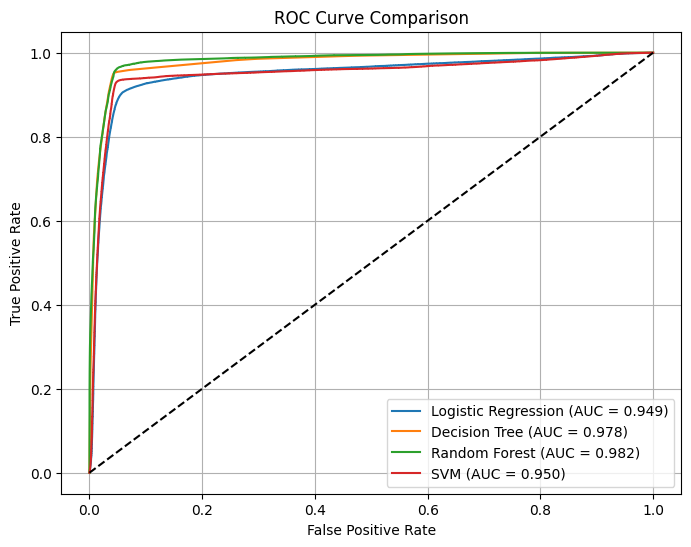

In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred
}

for name, pred in models.items():

    if name == "SVM":
        pdf = pred.select("label","rawPrediction").toPandas()
        scores = pdf["rawPrediction"].apply(lambda x: float(x[1]))
    else:
        pdf = pred.select("label","probability").toPandas()
        scores = pdf["probability"].apply(lambda x: float(x[1]))

    fpr, tpr, _ = roc_curve(pdf["label"], scores)

    roc_auc = sk_auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

Precision-Recall Curve

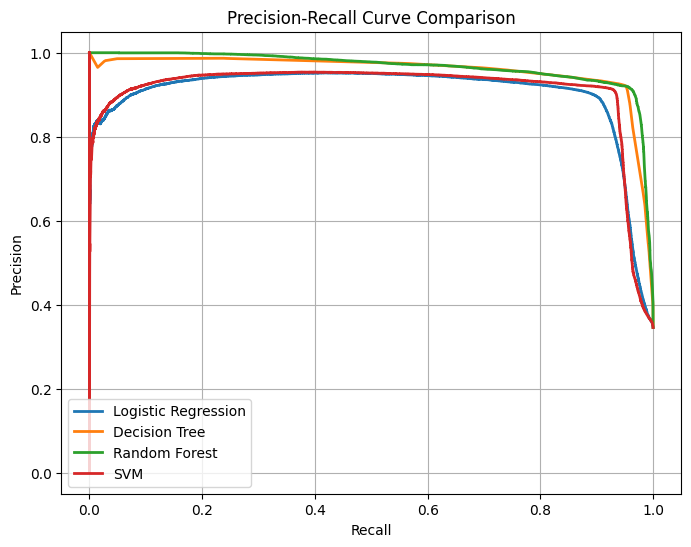

In [ ]:
plt.figure(figsize=(8,6))
for name, pred in models.items():
    if name == "SVM":
        pdf = pred.select("label", "rawPrediction").toPandas()
        scores = pdf["rawPrediction"].apply(lambda x: float(x[1]))
    else:
        pdf = pred.select("label", "probability").toPandas()
        scores = pdf["probability"].apply(lambda x: float(x[1]))

    precision, recall, _ = precision_recall_curve(
        pdf["label"],
        scores
    )
    plt.plot(recall, precision,
             linewidth=2,
             label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

Feature Importance

In [ ]:
importance = rf_model.bestModel.featureImportances.toArray()

rf_importance = pd.DataFrame({
    "Feature":selected_features,
    "Importance":importance
})

rf_importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
3,tip_amount,0.786677
9,RatecodeID,0.111710
2,fare_amount,0.034981
5,trip_duration_minutes,0.027122
4,total_amount,0.012633
1,trip_distance,0.010668
0,passenger_count,0.008836
6,average_speed,0.004623
7,PULocationID,0.002124
8,DOLocationID,0.000625


<Axes: ylabel='Feature'>

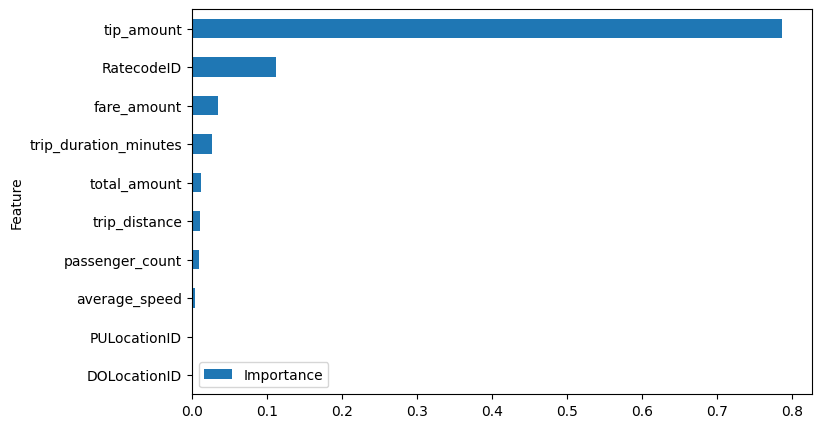

In [ ]:
rf_importance.sort_values(
    "Importance"
).plot.barh(
    x="Feature",
    y="Importance",
    figsize=(8,5)
)

# Task 6 -Tableau

Dashboard 1 — Data Quality & Pipeline Monitoring

In [ ]:
data_quality = pd.DataFrame({
"Metric":[
"Total Rows",
"Training Rows",
"Testing Rows",
"Features",
"Missing Values",
"Duplicate Rows"
],

"Value":[
total_rows,
train_df.count(),
test_df.count(),
10,
0,
duplicate_rows
]
})

data_quality.to_excel(
    "Dashboard1_Data_Quality.xlsx",
    index=False
)

Dashboard 2 — Model Performance

In [ ]:
metrics.to_excel(
    "Dashboard2_Model_Performance.xlsx",
    index=False
)

Dashboard 3 — Business Insights

In [ ]:
business = (
    df1.select(
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "payment_type"
    )
    .sample(False, 0.005, seed=42)
    .toPandas()
)

business.to_excel(
    "Dashboard3_Business_Insights.xlsx",
    index=False
)

Dashboard 4 — Scalability & Cost Analysis

In [ ]:
scalability = pd.DataFrame({
"Metric":[
"Number of Partitions",
"Executor Memory",
"Training Rows",
"Testing Rows",
"Training Time LR",
"Training Time DT",
"Training Time RF",
"Training Time SVM"
],

"Value":[
train_df.rdd.getNumPartitions(),
spark.conf.get("spark.executor.memory","Default"),
train_df.count(),
test_df.count(),
lr_training_time,
dt_training_time,
rf_training_time,
svm_training_time
]
})

scalability.to_excel(
    "Dashboard4_Scalability.xlsx",
    index=False
)